-Eksik yılları u değerleriyle sınıflandıran program.

-Scaling yapıldı.

-Kullanılan veriler "Materials_Yigma_Betonarme.xlsx" dosyasından alındı.(Dosya IP1 içerisinde bulunmuyor. Bana whatsapp üzerinden  ulaştırıldı.)





In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
import keras
import tensorflow as tf
from google.colab import drive

drive.mount("/content/drive", force_remount=True)
!ls

Mounted at /content/drive
drive  sample_data


In [ ]:
data=pd.read_csv("/content/drive/MyDrive/UBEM/u_val_final.csv")

In [ ]:
data["Date"]=pd.cut(data["Date"],bins=[1960,1980,2000,2200],labels=[0,1,2])
#data["Date"]=pd.get_dummies(data["Date"],prefix="YEAR")

one_hot=(pd.get_dummies(data["Date"],prefix="YEAR"))
print(data["Date"].value_counts().sort_index())

data=data.assign(YEAR0=one_hot["YEAR_0"],YEAR1=one_hot["YEAR_1"],YEAR2=one_hot["YEAR_2"])
data=data.drop(["Date"],1)
data["Yapi Türü"],indexes_usage_type = pd.factorize(data["Yapi Türü"])
data=data.dropna(axis="rows",how="any")


data["YEAR0"]=data["YEAR0"].astype(int)
data["YEAR1"]=data["YEAR1"].astype(int)
data["YEAR2"]=data["YEAR2"].astype(int)

print(data.dtypes)


y1=data[data["YEAR0"]== 1]
y2=data[data["YEAR1"]== 1]
y3=data[data["YEAR2"]== 1]     

print(len(y1.index))
print(len(y2.index))
print(len(y3.index))

length=data.shape[0]

data = data.sample(frac=1)

print("AAAAAAAAAAAAAAAA    ",data.head)

train_x = np.array(data[0:int(length*0.7)])[:,1:15].astype('float32') 
train_y = np.array(data[0:int(length*0.7)])[:,15:18].astype('float32')  
test_x = np.array(data[int(length*0.7):])[:,1:15].astype('float32') 
test_y = np.array(data[int(length*0.7):])[:,15:18].astype('float32') 

print("aa     " ,train_x[0:5])
print(train_y[0:5])

0    162
1    110
2     68
Name: Date, dtype: int64
Unnamed: 0                            int64
Block No                            float64
Parsel No                           float64
Yapi Türü                             int64
duvar ağırlıklı U değeri            float64
kolon agirlikli U degeri            float64
kiris agirlikli U degeri            float64
taban döseme agirlikli U degeri     float64
konsol döseme agirlikli U degeri    float64
cati agirlikli U degeri             float64
pencere agirlikli U degeri          float64
kapi agirlikli U degeri             float64
Temel U Degeri                      float64
Toplam Dis Duvar AlaniU Degeri      float64
Kagir Duvar Kalınlığı               float64
YEAR0                                 int64
YEAR1                                 int64
YEAR2                                 int64
dtype: object
162
110
68
AAAAAAAAAAAAAAAA     <bound method NDFrame.head of      Unnamed: 0  Block No  Parsel No  Yapi Türü  duvar ağırlıklı U değeri  \
209

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:8: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only
  


In [ ]:
model1 = keras.models.Sequential()

model1.add(keras.layers.Dense(14,activation="relu"))
model1.add(keras.layers.BatchNormalization())

model1.add(keras.layers.Dense(64,activation="relu"))
model1.add(keras.layers.BatchNormalization())
model1.add(keras.layers.Dropout(0.5))

model1.add(keras.layers.Dense(32,activation="relu"))
model1.add(keras.layers.BatchNormalization())
model1.add(keras.layers.Dropout(0.5))

model1.add(keras.layers.Dense(3,activation="softmax"))

class TerminateOnBaseline(keras.callbacks.Callback):

    def __init__(self, monitor='accuracy', baseline=0.9):
        super(TerminateOnBaseline, self).__init__()
        self.monitor = monitor
        self.baseline = baseline

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        acc = logs.get(self.monitor)
        if acc is not None:
            if acc >= self.baseline:
                print('Epoch %d: Reached baseline, terminating training' % (epoch))
                self.model.stop_training = True

arageri=keras.callbacks.EarlyStopping(monitor="val_loss", patience=5)
arageri2=TerminateOnBaseline(monitor="val_accuracy", baseline=0.55)

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.002,
    decay_steps=500,
    decay_rate=0.9)

adam = tf.keras.optimizers.Adam(learning_rate=lr_schedule,beta_1=0.9,beta_2=0.999, epsilon=1e-07  )

model1.compile(optimizer=adam, loss=keras.losses.CategoricalCrossentropy(), metrics=["accuracy"])

#model1.summary()

Epoch 1/500
15/15 [==============================] - 2s 32ms/step - loss: 1.7832 - accuracy: 0.3708 - val_loss: 2.2405 - val_accuracy: 0.2308
Epoch 2/500
15/15 [==============================] - 0s 8ms/step - loss: 1.6478 - accuracy: 0.3958 - val_loss: 1.7305 - val_accuracy: 0.2404
Epoch 3/500
15/15 [==============================] - 0s 8ms/step - loss: 1.3555 - accuracy: 0.4292 - val_loss: 1.4721 - val_accuracy: 0.2596
Epoch 4/500
15/15 [==============================] - 0s 12ms/step - loss: 1.4661 - accuracy: 0.4250 - val_loss: 1.2524 - val_accuracy: 0.2885
Epoch 5/500
15/15 [==============================] - 0s 8ms/step - loss: 1.4471 - accuracy: 0.3792 - val_loss: 1.1750 - val_accuracy: 0.3365
Epoch 6/500
15/15 [==============================] - 0s 9ms/step - loss: 1.4532 - accuracy: 0.4167 - val_loss: 1.1441 - val_accuracy: 0.3462
Epoch 7/500
15/15 [==============================] - 0s 8ms/step - loss: 1.2756 - accuracy: 0.4333 - val_loss: 1.1034 - val_accuracy: 0.3846
Epoch 8/500

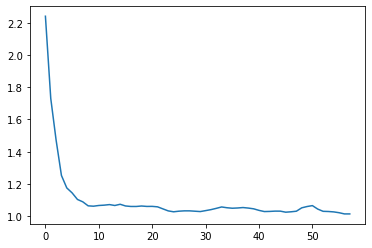

In [ ]:
#dengelenmemiş veri için 

history=model1.fit(train_x, train_y, validation_data=(test_x, test_y), epochs=500,batch_size=16,callbacks=[arageri2],verbose=1)

plot=plt.plot(np.arange(len(history.history["val_loss"])),history.history["val_loss"])
plt.show()  


In [ ]:
results=model1.predict(test_x)

In [ ]:
true = 0
false = 0

for i in range(len(test_x)):
  print(results[i])
  print( (np.where(results[i] == results[i].max()))[0] , np.where(test_y[i] == test_y[i].max())[0]   )
  print("___________________________________________")
  if len(np.where(test_y[i] == test_y[i].max())[0]) ==1   and (np.where(results[i] == results[i].max()))[0] ==  np.where(test_y[i] == test_y[i].max())[0] :
      true += 1
  else:
      false += 1  
print("True: ",true ,"False: ",false ) 

[0.37267098 0.36133662 0.26599246]
[0] [0]
___________________________________________
[0.37321696 0.57163554 0.05514754]
[1] [1]
___________________________________________
[0.4736696  0.32915232 0.19717804]
[0] [1]
___________________________________________
[0.41427457 0.338408   0.24731743]
[0] [0]
___________________________________________
[0.38401663 0.40393564 0.21204776]
[1] [1]
___________________________________________
[0.38949892 0.34589094 0.26461014]
[0] [2]
___________________________________________
[0.44670847 0.36952993 0.18376163]
[0] [2]
___________________________________________
[0.4184317  0.5369475  0.04462081]
[1] [2]
___________________________________________
[0.4166727  0.25756532 0.32576203]
[0] [1]
___________________________________________
[0.29893398 0.4057317  0.29533428]
[1] [1]
___________________________________________
[0.87702113 0.10576627 0.01721269]
[0] [0]
___________________________________________
[0.42202893 0.4847516  0.09321953]
[1] [1]


In [ ]:
#veri dengelenen bölüm
#print(data.columns.values)
'''
x=data.index[data['YEAR0'].eq(1.0)]
data_balanced = data.drop(np.random.choice(data.index[data['YEAR0'].eq(1)], 98))
data_balanced = data_balanced.drop(np.random.choice(data_balanced.index[data_balanced['YEAR1'].eq(1)], 40))

length_2=data.shape[0]

train_x2 = np.array(data_balanced.loc[0:length_2*0.7])[:,1:15].astype('float32') 
train_y2 = np.array(data_balanced.loc[0:length_2*0.7])[:,15:18].astype('float32')  
test_x2 = np.array(data_balanced.loc[length_2*0.7:])[:,1:15].astype('float32') 
test_y2 = np.array(data_balanced.loc[length_2*0.7:])[:,15:18].astype('float32')
'''
################################################################################

y1=data[data["YEAR0"]==1]
y2=data[data["YEAR1"]==1]
y3=data[data["YEAR2"]==1]

print(y1.shape[0])
print(y2.shape[0])
print(y3.shape[0])
print("_________________________________________________________________________")

y1=y1.iloc[:68,:]
y2=y2.iloc[:68,:]
y3=y3.iloc[:68,:]

print(y1.shape[0])
print(y2.shape[0])
print(y3.shape[0])

length=y1.shape[0]

a = y1[0:int(length*0.7)]
b = y2[0:int(length*0.7)]
c = y3[0:int(length*0.7)]

d = y1[int(length*0.7):]
e = y2[int(length*0.7):]
f = y3[int(length*0.7):]

train_data = pd.concat([a, b, c], ignore_index=True)
test_data = pd.concat([d ,e,f], ignore_index=True )

train_data=train_data.sample(frac=1)
test_data=test_data.sample(frac=1)

length2=data.shape[0]
train_x2 = np.array(train_data)[:,1:15].astype('float32') 
train_y2 = np.array(train_data)[:,15:18].astype('float32')  
test_x2 = np.array(test_data)[:,1:15].astype('float32') 
test_y2 = np.array(test_data)[:,15:18].astype('float32') 

print(train_x2.shape, train_y2.shape)
print(train_x2[0:5])


162
110
68
_________________________________________________________________________
68
68
68
(141, 14) (141, 3)
[[48.    7.    0.    1.26  3.02  3.02  1.93  0.    0.31  3.    3.67  1.93
   1.26  0.19]
 [31.    8.    0.    0.46  0.5   0.5   2.01  0.    0.55  3.3   5.5   2.01
   0.46  0.19]
 [23.    5.    2.    1.2   3.01  3.24  0.75  0.5   0.43  2.9   3.72  0.75
   1.46  0.2 ]
 [ 8.    1.    2.    0.49  3.25  3.17  0.61  0.36  0.47  2.9   3.95  0.61
   0.49  0.18]
 [ 7.    3.    0.    0.49  0.51  0.5   0.45  0.47  1.52  2.9   3.92  0.45
   0.49  0.18]]


In [ ]:
model2 = keras.models.Sequential()

model2.add(keras.layers.Dense(14,activation="relu"))
model2.add(keras.layers.BatchNormalization())

model2.add(keras.layers.Dense(64,activation="relu"))
model2.add(keras.layers.BatchNormalization())
model2.add(keras.layers.Dropout(0.5))

model2.add(keras.layers.Dense(32,activation="relu"))
model2.add(keras.layers.BatchNormalization())
model2.add(keras.layers.Dropout(0.5))

model2.add(keras.layers.Dense(16,activation="relu"))
model2.add(keras.layers.BatchNormalization())
model2.add(keras.layers.Dropout(0.5))

model2.add(keras.layers.Dense(3,activation="softmax"))

arageri=keras.callbacks.EarlyStopping(monitor="val_loss", patience=20)
arageri3=TerminateOnBaseline(monitor="val_accuracy", baseline=0.5)

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.002,
    decay_steps=100,
    decay_rate=0.9)

adam = tf.keras.optimizers.Adam(learning_rate=lr_schedule,beta_1=0.9,beta_2=0.999, epsilon=1e-07  )

model2.compile(optimizer=adam, loss=keras.losses.CategoricalCrossentropy(), metrics=["accuracy"])

#model2.summary()

Epoch 1/500
9/9 [==============================] - 2s 49ms/step - loss: 1.7192 - accuracy: 0.3475 - val_loss: 1.1210 - val_accuracy: 0.3651
Epoch 2/500
9/9 [==============================] - 0s 13ms/step - loss: 1.8865 - accuracy: 0.3191 - val_loss: 1.1079 - val_accuracy: 0.3492
Epoch 3/500
9/9 [==============================] - 0s 15ms/step - loss: 1.5242 - accuracy: 0.4043 - val_loss: 1.1123 - val_accuracy: 0.3492
Epoch 4/500
9/9 [==============================] - 0s 14ms/step - loss: 1.6967 - accuracy: 0.3050 - val_loss: 1.1246 - val_accuracy: 0.3492
Epoch 5/500
9/9 [==============================] - 0s 14ms/step - loss: 1.4784 - accuracy: 0.3830 - val_loss: 1.1410 - val_accuracy: 0.3016
Epoch 6/500
9/9 [==============================] - 0s 14ms/step - loss: 1.7008 - accuracy: 0.3050 - val_loss: 1.1518 - val_accuracy: 0.2857
Epoch 7/500
9/9 [==============================] - 0s 15ms/step - loss: 1.4454 - accuracy: 0.3262 - val_loss: 1.1694 - val_accuracy: 0.2381
Epoch 8/500
9/9 [===

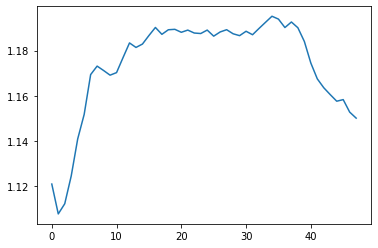

In [ ]:
#dengelenmiş veri için 

history2=model2.fit(train_x2, train_y2, validation_data=(test_x2, test_y2), epochs=500,batch_size=16,callbacks=[arageri3],verbose=1)

plot=plt.plot(np.arange(len(history2.history["val_loss"])),history2.history["val_loss"])
plt.show()  

In [ ]:
model2.save("/content/drive/MyDrive/UBEM/u_val_clas_1_balanced")
results=model2.predict(test_x2)

INFO:tensorflow:Assets written to: /content/drive/MyDrive/UBEM/u_val_clas_1_balanced/assets


In [ ]:
true = 0
false = 0

succesfull_preds = {"0":0  , "1" :0  , "2"  :0}
unsuccesfull_preds = {"0":0  , "1" :0  , "2"  :0}

for i in range(len(test_x2)):
    print(results[i])
    print( (np.where(results[i] == results[i].max()))[0] , np.where(test_y2[i] == test_y2[i].max())[0]   )
    
    if len(np.where(test_y2[i] == test_y2[i].max())[0]) == 1   and (np.where(results[i] == results[i].max()))[0] ==  np.where(test_y2[i] == test_y2[i].max())[0] :
        
        true += 1
        succesfull_preds[str(np.where(test_y2[i] == test_y2[i].max())[0][0])] += 1
    else:
        
        unsuccesfull_preds[str(np.where(test_y2[i] == test_y2[i].max())[0][0])] += 1
        false += 1  

    print("___________________________________________")


print("True: ",true ,"False: ",false ) 
print("True: " ,succesfull_preds  ,"False: ",unsuccesfull_preds        )

[0.34420404 0.29503864 0.3607573 ]
[2] [2]
___________________________________________
[0.2517182  0.49152532 0.25675648]
[1] [0]
___________________________________________
[0.3267226  0.39394158 0.27933577]
[1] [1]
___________________________________________
[0.35617203 0.2739536  0.36987433]
[2] [1]
___________________________________________
[0.22862397 0.19689877 0.57447726]
[2] [0]
___________________________________________
[0.32449517 0.2745601  0.4009447 ]
[2] [2]
___________________________________________
[0.22932756 0.28053275 0.4901396 ]
[2] [2]
___________________________________________
[0.21791615 0.19641823 0.5856656 ]
[2] [2]
___________________________________________
[0.35993692 0.33570775 0.3043553 ]
[0] [2]
___________________________________________
[0.42179745 0.27995536 0.29824716]
[0] [0]
___________________________________________
[0.34907302 0.31936085 0.3315661 ]
[0] [2]
___________________________________________
[0.23912169 0.4412833  0.31959498]
[1] [0]


Yaptığın değişikliklerle ilgili buraya not bırakabilirsin bazen programın son halini unutabiliyorum:

-

-

-

-

-











